# Leakage classifiers

This notebook contains the retained classifier analyses for the 1,320-run J-Lens dataset:

1. one independent model per transformer layer, using the complete user prompt and prompt scaffolding;
2. one independent model per token position, using compact features from Layers 16–31;
3. one joint XGBoost classifier combining the user-message tail from 80% onward, all prompt scaffolding, and Layers 16–31.

Every reported score uses `GroupKFold` by `category`; `control` is explicitly treated as one ordinary category group. Response positions and prompt metadata are excluded from model features. These are predictive associations, not causal results.

In [1]:
%pip install -q pandas numpy scipy scikit-learn matplotlib seaborn xgboost


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: /Users/christinck/Documents/j-lens-capstone/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import math
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix, hstack, lil_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "outputs").exists()
)
INPUT_FILE = (
    ROOT / "outputs" / "j-lens-run" /
    "qwen35-4b-full-corpus-user-response-positions-top10.jsonl"
)

LAYERS = list(range(32))
SECOND_HALF_LAYERS = list(range(16, 32))
TOP_K = 10
N_SPLITS = 6
MIN_TOKEN_DF = 10
RANDOM_STATE = 42
SECRET_TOKEN = "banana"
SECRET_TOKEN_ID = 84721
N_SUFFIX_POSITIONS = 9

LOGISTIC_C = 0.03
XGBOOST_PARAMS = {
    "n_estimators": 400,
    "max_depth": 3,
    "learning_rate": 0.03,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
}


def iter_examples():
    with INPUT_FILE.open(encoding="utf-8") as file:
        for line in file:
            if line.strip():
                yield json.loads(line)


def make_classifier(model_kind, y_train, xgboost_params=None):
    if model_kind == "logistic":
        return LogisticRegression(
            solver="liblinear",
            class_weight="balanced",
            C=LOGISTIC_C,
            max_iter=3000,
            random_state=RANDOM_STATE,
        )

    params = XGBOOST_PARAMS if xgboost_params is None else xgboost_params
    positives = y_train.sum()
    negatives = len(y_train) - positives
    return XGBClassifier(
        **params,
        scale_pos_weight=negatives / positives,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


def metric_summary(y, oof_probability, fold_aucs, feature_counts):
    prediction = (oof_probability >= 0.5).astype(int)
    return {
        "mean_fold_auc": float(np.mean(fold_aucs)),
        "fold_auc_std": float(np.std(fold_aucs)),
        "oof_auc": float(roc_auc_score(y, oof_probability)),
        "oof_accuracy": float(accuracy_score(y, prediction)),
        "oof_balanced_accuracy": float(balanced_accuracy_score(y, prediction)),
        "mean_features": float(np.mean(feature_counts)),
        "n": len(y),
    }

## Dataset and scope check

The 1 GB JSONL contains readouts from the first user token through the generated response. Every extractor below enforces `position < response_start_position`; this retains user content plus nine prompt-suffix/scaffolding tokens and excludes every response activation.

In [3]:
overview_rows = []
for example in iter_examples():
    assert example["secret"] == SECRET_TOKEN
    assert example["probe"]["token_id"] == SECRET_TOKEN_ID
    prompt_readouts = {
        int(position): readout
        for position, readout in example["readouts"].items()
        if int(position) < example["response_start_position"]
    }
    assert prompt_readouts
    assert all(readout["segment"] != "response" for readout in prompt_readouts.values())
    assert sum(readout["segment"] == "prompt_suffix" for readout in prompt_readouts.values()) == N_SUFFIX_POSITIONS
    overview_rows.append({
        "label": example["label"],
        "category": example["category"],
        "target": int(example["attack_successful"]),
    })

overview_df = pd.DataFrame(overview_rows)
display(pd.DataFrame({
    "runs": [len(overview_df)],
    "attacks": [(overview_df["label"] == "attack").sum()],
    "benign": [(overview_df["label"] == "benign").sum()],
    "leaked": [overview_df["target"].sum()],
    "leak_rate": [overview_df["target"].mean()],
    "categories": [overview_df["category"].nunique()],
}))

,runs,attacks,benign,leaked,leak_rate,categories
0,1320,924,396,458,0.34697,12


## A. One model per transformer layer

**Quick feature summary**

- One row represents one prompt run. A separate Logistic Regression and XGBoost model is trained for each transformer layer.
- Positions are represented by 14 groups: five relative user-message bins (`0–20%`, ..., `80–100%`) and nine exact scaffolding positions.
- In each cross-validation fold, the 300 most frequent Top-10 readout tokens are selected from the training rows only.
- The resulting `14 position groups × 300 tokens = 4,200` features are named conceptually as `max_logit[position_group, token]`. A value is the strongest logit for that token within the position group at the model's single transformer layer; absent combinations are zero in the sparse matrix.
- Secret-token rank, response readouts, category, prompt text and other metadata are not features. The secret can only occur like any other token if it is naturally selected into the fold vocabulary.

In [4]:
USER_BINS = ["user_0_20", "user_20_40", "user_40_60", "user_60_80", "user_80_100"]
SUFFIX_GROUPS = [f"prompt_suffix_{index}" for index in range(1, N_SUFFIX_POSITIONS + 1)]
LAYER_POSITION_GROUPS = USER_BINS + SUFFIX_GROUPS


def load_layer_records(layer):
    records = []
    for example in iter_examples():
        selected = sorted(
            (int(position), readout)
            for position, readout in example["readouts"].items()
            if int(position) < example["response_start_position"]
        )
        user_positions = [position for position, readout in selected if readout["segment"] == "user"]
        suffix_positions = [position for position, readout in selected if readout["segment"] == "prompt_suffix"]
        position_groups = {
            position: USER_BINS[min(4, math.floor(offset * 5 / len(user_positions)))]
            for offset, position in enumerate(user_positions)
        }
        position_groups.update({
            position: SUFFIX_GROUPS[offset]
            for offset, position in enumerate(suffix_positions)
        })

        token_logits = {}
        for position, readout in selected:
            group = position_groups[position]
            top_k = readout["layers"][str(layer)]["top_k"]
            for token_id, logit in zip(top_k["token_ids"], top_k["logits"]):
                key = (group, token_id)
                token_logits[key] = max(token_logits.get(key, -np.inf), logit)

        records.append({
            "target": int(example["attack_successful"]),
            "group": example["category"],
            "token_logits": token_logits,
        })
    return records


def layer_vocabulary(records, train_indices):
    frequency = Counter()
    for index in train_indices:
        frequency.update({token_id for _, token_id in records[index]["token_logits"]})
    tokens = [token_id for token_id, count in frequency.items() if count >= MIN_TOKEN_DF]
    tokens.sort(key=lambda token_id: (-frequency[token_id], token_id))
    return tokens[:300]


def layer_matrix(records, indices, vocabulary):
    token_column = {token_id: column for column, token_id in enumerate(vocabulary)}
    group_offset = {group: offset for offset, group in enumerate(LAYER_POSITION_GROUPS)}
    matrix = lil_matrix((len(indices), len(LAYER_POSITION_GROUPS) * len(vocabulary)), dtype=np.float32)
    for row, index in enumerate(indices):
        for (group, token_id), logit in records[index]["token_logits"].items():
            column = token_column.get(token_id)
            if column is not None:
                matrix[row, group_offset[group] * len(vocabulary) + column] = logit
    return matrix.tocsr()


def evaluate_layer(records, model_kind):
    y = np.array([record["target"] for record in records])
    groups = np.array([record["group"] for record in records])
    splitter = GroupKFold(n_splits=N_SPLITS)
    oof_probability = np.full(len(records), np.nan)
    fold_aucs, feature_counts = [], []

    for train_indices, test_indices in splitter.split(np.zeros(len(records)), y, groups):
        vocabulary = layer_vocabulary(records, train_indices)
        X_train = layer_matrix(records, train_indices, vocabulary)
        X_test = layer_matrix(records, test_indices, vocabulary)
        if model_kind == "logistic":
            scaler = StandardScaler(with_mean=False)
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        classifier = make_classifier(model_kind, y[train_indices])
        classifier.fit(X_train, y[train_indices])
        probability = classifier.predict_proba(X_test)[:, 1]
        oof_probability[test_indices] = probability
        feature_counts.append(X_train.shape[1])
        if len(np.unique(y[test_indices])) == 2:
            fold_aucs.append(roc_auc_score(y[test_indices], probability))
    return metric_summary(y, oof_probability, fold_aucs, feature_counts)

Done layer 0


Done layer 1


Done layer 2


Done layer 3


Done layer 4


...

Done layer 28


Done layer 29


Done layer 30


Done layer 31


,layer,model,mean_fold_auc,fold_auc_std,oof_auc,oof_accuracy,oof_balanced_accuracy,mean_features,n
18,9,logistic,0.729443,0.042954,0.693609,0.662121,0.655853,4200.0,1320
58,29,logistic,0.727008,0.101525,0.764737,0.717424,0.690521,4200.0,1320
22,11,logistic,0.719504,0.025238,0.648226,0.621212,0.615832,4200.0,1320
62,31,logistic,0.712846,0.052571,0.729364,0.680303,0.683077,4200.0,1320
48,24,logistic,0.707983,0.075224,0.695346,0.665909,0.659265,4200.0,1320
53,26,xgboost,0.785921,0.021364,0.813858,0.753030,0.739785,4200.0,1320
63,31,xgboost,0.779200,0.030149,0.763782,0.717424,0.710476,4200.0,1320
49,24,xgboost,0.771047,0.041339,0.774582,0.697727,0.704093,4200.0,1320
47,23,xgboost,0.759680,0.025684,0.761464,0.688636,0.693551,4200.0,1320
51,25,xgboost,0.756882,0.020665,0.748556,0.692424,0.690823,4200.0,1320


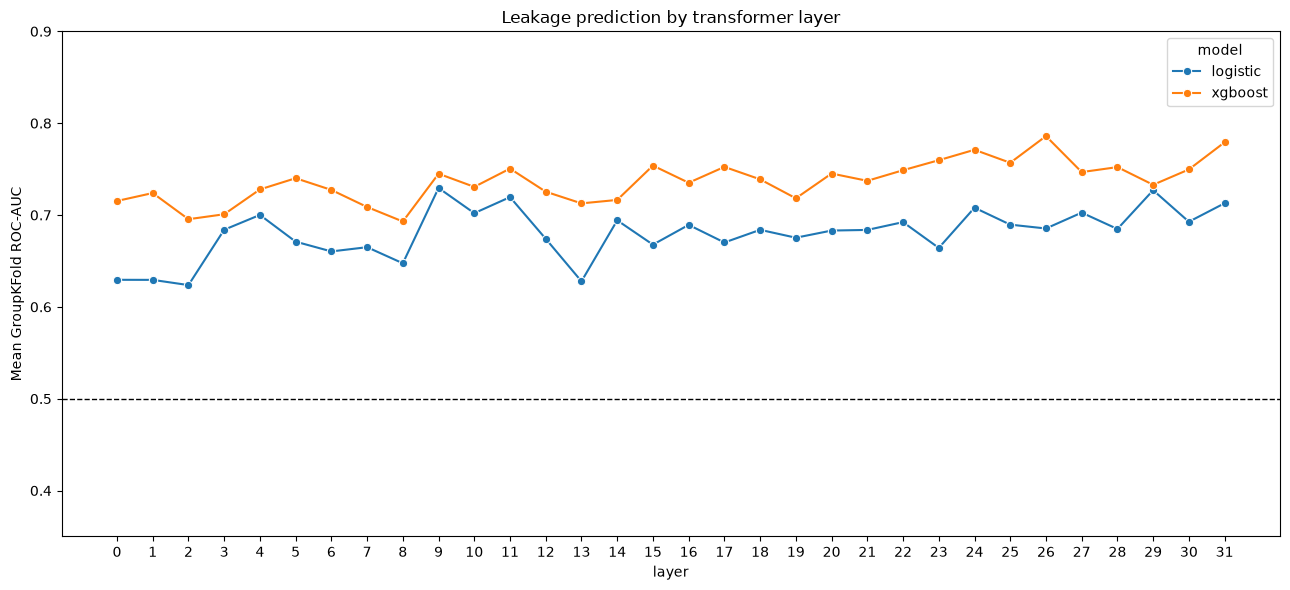

In [5]:
layer_results = []
for layer in LAYERS:
    records = load_layer_records(layer)
    for model_kind in ["logistic", "xgboost"]:
        layer_results.append({
            "layer": layer,
            "model": model_kind,
            **evaluate_layer(records, model_kind),
        })
    print("Done layer", layer)

layer_results_df = pd.DataFrame(layer_results)
display(
    layer_results_df.sort_values("mean_fold_auc", ascending=False)
    .groupby("model", as_index=False).head(5)
    .sort_values(["model", "mean_fold_auc"], ascending=[True, False])
)

plt.figure(figsize=(13, 6))
sns.lineplot(data=layer_results_df, x="layer", y="mean_fold_auc", hue="model", marker="o")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xticks(LAYERS)
plt.ylim(0.35, 0.90)
plt.ylabel("Mean GroupKFold ROC-AUC")
plt.title("Leakage prediction by transformer layer")
plt.tight_layout()
plt.show()

## B. One model per token position

**Quick feature summary**

A separate model is trained for each token-position definition: relative user positions `0%`, `10%`, ..., `90%`; exact `last_user`; exact scaffolding positions 1–8; and exact `last_prompt` (scaffolding position 9). Every model uses only its one selected token position and Layers 16–31.

- **Logistic Regression — 48 final features:** Start with `16 layers × 100 fold-locally frequent tokens = 1,600` sparse columns named conceptually as `logit[layer, token]`. Truncated SVD, fitted only on the training fold, turns these into 32 components. Append `log(secret_rank_L16)` through `log(secret_rank_L31)` as 16 separate features.
- **XGBoost — 176 final features:** Keep ten fold-locally frequent tokens separate at every layer: `logit[L16, token_1]` through `logit[L31, token_10]`, giving 160 token-logit features. Append the same 16 `log(secret_rank_L16)` through `log(secret_rank_L31)` features.
- The selected token IDs can differ between position definitions and cross-validation folds; they are chosen from training data only. An absent token-layer combination is zero in the sparse matrix. Generic rank-1-to-rank-10 logits are not included. Category, response readouts and prompt metadata are not features.

In [6]:
POSITION_SPECS = {
    **{f"user_{percent:02d}%": ("user_relative", percent / 100) for percent in range(0, 100, 10)},
    "last_user": ("last_user", None),
    **{f"prompt_suffix_{index}": ("prompt_suffix", index - 1) for index in range(1, N_SUFFIX_POSITIONS)},
    "last_prompt": ("prompt_suffix", N_SUFFIX_POSITIONS - 1),
}
POSITION_ORDER = list(POSITION_SPECS)


def prompt_position_parts(example):
    selected = sorted(
        (int(position), readout)
        for position, readout in example["readouts"].items()
        if int(position) < example["response_start_position"]
    )
    user_positions = [position for position, readout in selected if readout["segment"] == "user"]
    suffix_positions = [position for position, readout in selected if readout["segment"] == "prompt_suffix"]
    return user_positions, suffix_positions


def select_position(example, position_name):
    user_positions, suffix_positions = prompt_position_parts(example)
    position_type, value = POSITION_SPECS[position_name]
    if position_type == "user_relative":
        return user_positions[round(value * (len(user_positions) - 1))]
    if position_type == "last_user":
        return user_positions[-1]
    return suffix_positions[value]


def load_position_records(position_name):
    records = []
    for example in iter_examples():
        position = select_position(example, position_name)
        assert position < example["response_start_position"]
        readout = example["readouts"][str(position)]
        token_logits, secret_ranks = {}, {}
        for layer in SECOND_HALF_LAYERS:
            layer_readout = readout["layers"][str(layer)]
            for token_id, logit in zip(layer_readout["top_k"]["token_ids"], layer_readout["top_k"]["logits"]):
                token_logits[(layer, token_id)] = logit
            secret_ranks[layer] = int(layer_readout["probe"]["rank"])
        records.append({
            "target": int(example["attack_successful"]),
            "group": example["category"],
            "token_logits": token_logits,
            "secret_ranks": secret_ranks,
        })
    return records


def position_vocabulary(records, train_indices, size):
    frequency = Counter()
    for index in train_indices:
        frequency.update({token_id for _, token_id in records[index]["token_logits"]})
    tokens = [token_id for token_id, count in frequency.items() if count >= MIN_TOKEN_DF]
    tokens.sort(key=lambda token_id: (-frequency[token_id], token_id))
    return tokens[:size]


def position_token_matrix(records, indices, vocabulary):
    token_column = {token_id: column for column, token_id in enumerate(vocabulary)}
    layer_offset = {layer: offset for offset, layer in enumerate(SECOND_HALF_LAYERS)}
    matrix = lil_matrix((len(indices), 16 * len(vocabulary)), dtype=np.float32)
    for row, index in enumerate(indices):
        for (layer, token_id), logit in records[index]["token_logits"].items():
            column = token_column.get(token_id)
            if column is not None:
                matrix[row, layer_offset[layer] * len(vocabulary) + column] = logit
    return matrix.tocsr()


def position_rank_matrix(records, indices):
    return csr_matrix(np.asarray([
        [np.log(records[index]["secret_ranks"][layer]) for layer in SECOND_HALF_LAYERS]
        for index in indices
    ], dtype=np.float32))


def evaluate_position(records, model_kind):
    y = np.array([record["target"] for record in records])
    groups = np.array([record["group"] for record in records])
    splitter = GroupKFold(n_splits=N_SPLITS)
    oof_probability = np.full(len(records), np.nan)
    fold_aucs, feature_counts = [], []

    for train_indices, test_indices in splitter.split(np.zeros(len(records)), y, groups):
        vocabulary_size = 100 if model_kind == "logistic" else 10
        vocabulary = position_vocabulary(records, train_indices, vocabulary_size)
        X_train_tokens = position_token_matrix(records, train_indices, vocabulary)
        X_test_tokens = position_token_matrix(records, test_indices, vocabulary)
        if model_kind == "logistic":
            svd = TruncatedSVD(n_components=32, n_iter=7, random_state=RANDOM_STATE)
            X_train_tokens = csr_matrix(svd.fit_transform(X_train_tokens))
            X_test_tokens = csr_matrix(svd.transform(X_test_tokens))
        X_train = hstack([X_train_tokens, position_rank_matrix(records, train_indices)], format="csr")
        X_test = hstack([X_test_tokens, position_rank_matrix(records, test_indices)], format="csr")
        if model_kind == "logistic":
            scaler = StandardScaler(with_mean=False)
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        classifier = make_classifier(model_kind, y[train_indices])
        classifier.fit(X_train, y[train_indices])
        probability = classifier.predict_proba(X_test)[:, 1]
        oof_probability[test_indices] = probability
        feature_counts.append(X_train.shape[1])
        if len(np.unique(y[test_indices])) == 2:
            fold_aucs.append(roc_auc_score(y[test_indices], probability))
    return metric_summary(y, oof_probability, fold_aucs, feature_counts)

Done position user_00%


Done position user_10%


Done position user_20%


Done position user_30%


Done position user_40%


...

Done position prompt_suffix_7


Done position prompt_suffix_8


Done position last_prompt


,position,model,mean_fold_auc,fold_auc_std,oof_auc,oof_accuracy,oof_balanced_accuracy,mean_features,n
28,prompt_suffix_4,logistic,0.757340,0.015388,0.748637,0.672727,0.695184,48.0,1320
36,prompt_suffix_8,logistic,0.755089,0.042323,0.772576,0.720455,0.725076,48.0,1320
38,last_prompt,logistic,0.749423,0.036496,0.717783,0.630303,0.644282,48.0,1320
32,prompt_suffix_6,logistic,0.749318,0.042345,0.764977,0.723485,0.724838,48.0,1320
30,prompt_suffix_5,logistic,0.735847,0.035597,0.706448,0.593182,0.632233,48.0,1320
31,prompt_suffix_5,xgboost,0.761447,0.057202,0.704749,0.601515,0.624287,176.0,1320
39,last_prompt,xgboost,0.757643,0.056651,0.754362,0.698485,0.689323,176.0,1320
33,prompt_suffix_6,xgboost,0.746103,0.085657,0.695098,0.643939,0.660863,176.0,1320
37,prompt_suffix_8,xgboost,0.735161,0.056169,0.725458,0.687879,0.683761,176.0,1320
27,prompt_suffix_3,xgboost,0.733582,0.041338,0.758060,0.671212,0.685326,176.0,1320


,position,model,mean_fold_auc,fold_auc_std,oof_auc,oof_accuracy,oof_balanced_accuracy,mean_features,n
38,last_prompt,logistic,0.749423,0.036496,0.717783,0.630303,0.644282,48.0,1320
39,last_prompt,xgboost,0.757643,0.056651,0.754362,0.698485,0.689323,176.0,1320


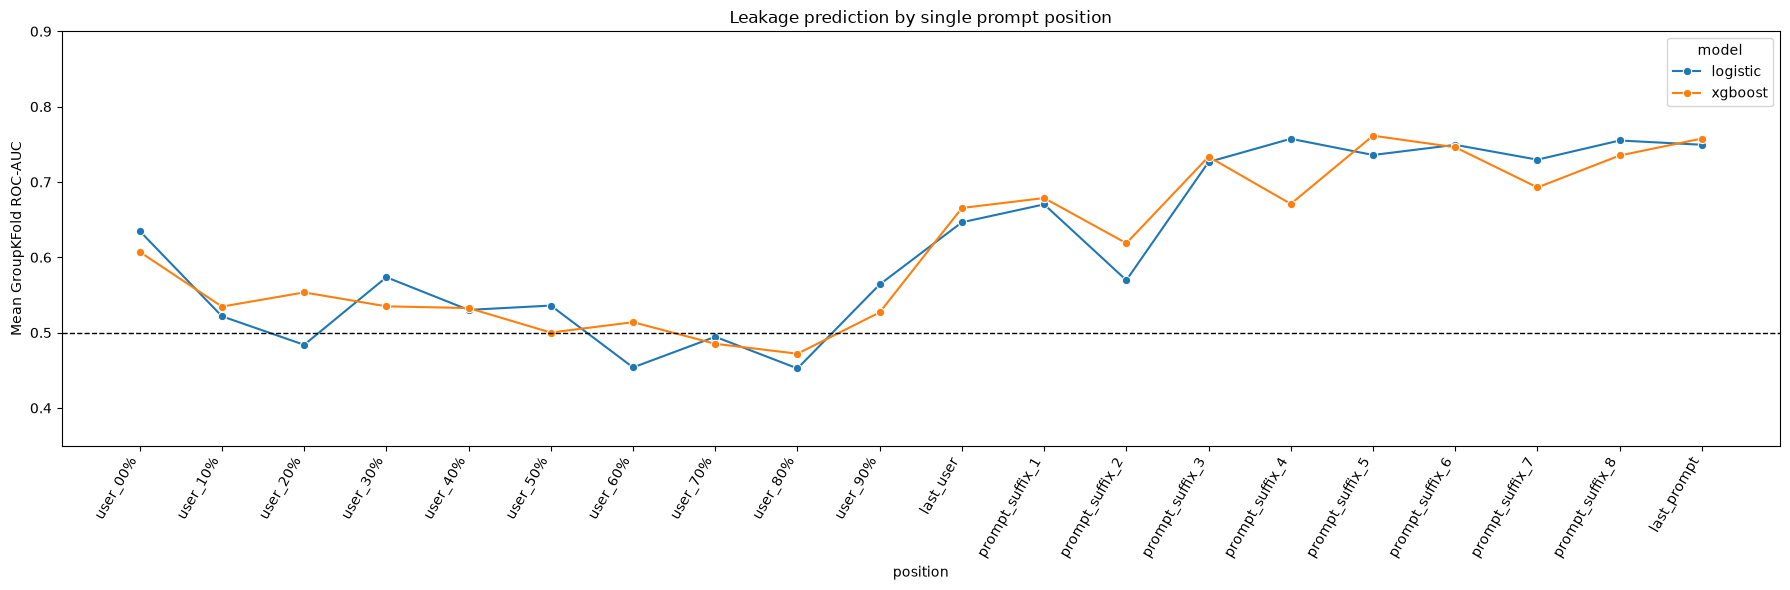

In [7]:
position_results = []
for position_name in POSITION_ORDER:
    records = load_position_records(position_name)
    for model_kind in ["logistic", "xgboost"]:
        position_results.append({
            "position": position_name,
            "model": model_kind,
            **evaluate_position(records, model_kind),
        })
    print("Done position", position_name)

position_results_df = pd.DataFrame(position_results)
position_results_df["position"] = pd.Categorical(
    position_results_df["position"], categories=POSITION_ORDER, ordered=True
)
display(
    position_results_df.sort_values("mean_fold_auc", ascending=False)
    .groupby("model", observed=True, as_index=False).head(5)
    .sort_values(["model", "mean_fold_auc"], ascending=[True, False])
)
display(position_results_df[position_results_df["position"] == "last_prompt"])

plt.figure(figsize=(18, 6))
sns.lineplot(data=position_results_df, x="position", y="mean_fold_auc", hue="model", marker="o")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.ylim(0.35, 0.90)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Mean GroupKFold ROC-AUC")
plt.title("Leakage prediction by single prompt position")
plt.tight_layout()
plt.show()

## C. One joint classifier: user tail ≥80% × scaffolding × Layers 16–31

**Quick feature summary of the selected joint model**

- One row represents one prompt run. One model combines 11 position groups and Layers 16–31: the user-message tail from 80% onward, an explicit exact `last_user` group, and nine exact scaffolding positions. The last user token is deliberately represented both inside the pooled tail and separately.
- For each fold, start with the 50 most frequent training-fold tokens and preserve position and layer identity: `11 groups × 16 layers × 50 tokens = 8,800` candidate `max_logit[position_group, layer, token]` columns. Within the pooled user tail, repeated tokens use their strongest logit.
- Training-fold ANOVA F-scores select 64 of those token-logit columns. Append `11 groups × 16 layers = 176` separate `log(secret_rank[position_group, layer])` features; for the pooled tail, the secret's best (lowest) rank is used. Final feature count: `64 + 176 = 240`.
- Response readouts, category, prompt text and metadata are excluded. Category is used only to form `GroupKFold` splits.

The cells below also compare seven compact representations and three small XGBoost parameter settings. Generic rank-1-to-rank-10 logits are not used.

In [8]:
JOINT_GROUPS = ["user_tail_80_100", "last_user"] + SUFFIX_GROUPS


def load_joint_records():
    records = []
    for example in iter_examples():
        user_positions, suffix_positions = prompt_position_parts(example)
        tail_start = math.floor(0.8 * len(user_positions))
        tail_positions = user_positions[tail_start:]
        grouped_positions = [(position, "user_tail_80_100") for position in tail_positions]
        grouped_positions.append((user_positions[-1], "last_user"))
        grouped_positions.extend(
            (position, SUFFIX_GROUPS[offset])
            for offset, position in enumerate(suffix_positions)
        )

        token_logits, secret_ranks = {}, {}
        for position, position_group in grouped_positions:
            readout = example["readouts"][str(position)]
            assert position < example["response_start_position"] and readout["segment"] != "response"
            for layer in SECOND_HALF_LAYERS:
                layer_readout = readout["layers"][str(layer)]
                for token_id, logit in zip(layer_readout["top_k"]["token_ids"], layer_readout["top_k"]["logits"]):
                    key = (position_group, layer, token_id)
                    token_logits[key] = max(token_logits.get(key, -np.inf), logit)
                rank_key = (position_group, layer)
                rank = int(layer_readout["probe"]["rank"])
                secret_ranks[rank_key] = min(secret_ranks.get(rank_key, rank), rank)

        assert len(secret_ranks) == len(JOINT_GROUPS) * len(SECOND_HALF_LAYERS)
        records.append({
            "target": int(example["attack_successful"]),
            "group": example["category"],
            "token_logits": token_logits,
            "secret_ranks": secret_ranks,
        })
    return records


JOINT_FEATURE_CONFIGS = {
    "secret ranks only": {"representation": "none", "vocabulary_size": 0, "reducer": None},
    "global pooled top 25": {"representation": "global", "vocabulary_size": 25, "reducer": None},
    "position-group top 10": {"representation": "position", "vocabulary_size": 10, "reducer": None},
    "layer-aware top 10": {"representation": "layer", "vocabulary_size": 10, "reducer": None},
    "position×layer top 5": {"representation": "full", "vocabulary_size": 5, "reducer": None},
    "position×layer SVD 64": {"representation": "full", "vocabulary_size": 50, "reducer": ("svd", 64)},
    "position×layer supervised 64": {"representation": "full", "vocabulary_size": 50, "reducer": ("f_score", 64)},
}

JOINT_XGBOOST_CONFIGS = {
    "shallow": {
        "n_estimators": 300, "max_depth": 2, "learning_rate": 0.05,
        "min_child_weight": 5, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0,
    },
    "standard": XGBOOST_PARAMS,
    "faster": {
        "n_estimators": 250, "max_depth": 3, "learning_rate": 0.05,
        "min_child_weight": 3, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0,
    },
}


def joint_vocabulary(records, train_indices, size):
    frequency = Counter()
    for index in train_indices:
        frequency.update({token_id for _, _, token_id in records[index]["token_logits"]})
    tokens = [token_id for token_id, count in frequency.items() if count >= MIN_TOKEN_DF]
    tokens.sort(key=lambda token_id: (-frequency[token_id], token_id))
    return tokens[:size]


def joint_token_matrix(records, indices, vocabulary, representation):
    token_column = {token_id: column for column, token_id in enumerate(vocabulary)}
    position_offset = {group: offset for offset, group in enumerate(JOINT_GROUPS)}
    layer_offset = {layer: offset for offset, layer in enumerate(SECOND_HALF_LAYERS)}
    widths = {
        "global": len(vocabulary),
        "position": len(JOINT_GROUPS) * len(vocabulary),
        "layer": 16 * len(vocabulary),
        "full": len(JOINT_GROUPS) * 16 * len(vocabulary),
    }
    matrix = lil_matrix((len(indices), widths[representation]), dtype=np.float32)

    for row, index in enumerate(indices):
        pooled = {}
        for (position_group, layer, token_id), logit in records[index]["token_logits"].items():
            token_index = token_column.get(token_id)
            if token_index is None:
                continue
            if representation == "global":
                column = token_index
            elif representation == "position":
                column = position_offset[position_group] * len(vocabulary) + token_index
            elif representation == "layer":
                column = layer_offset[layer] * len(vocabulary) + token_index
            else:
                column = (
                    (position_offset[position_group] * 16 + layer_offset[layer]) * len(vocabulary)
                    + token_index
                )
            pooled[column] = max(pooled.get(column, -np.inf), logit)
        for column, logit in pooled.items():
            matrix[row, column] = logit
    return matrix.tocsr()


def joint_rank_matrix(records, indices):
    return csr_matrix(np.asarray([
        [
            np.log(records[index]["secret_ranks"][(position_group, layer)])
            for position_group in JOINT_GROUPS for layer in SECOND_HALF_LAYERS
        ]
        for index in indices
    ], dtype=np.float32))


def reduce_fold(X_train, X_test, reducer, y_train):
    if reducer is None:
        return X_train, X_test
    reducer_name, size = reducer
    size = min(size, X_train.shape[1])
    if reducer_name == "svd":
        svd = TruncatedSVD(n_components=size, n_iter=7, random_state=RANDOM_STATE)
        return csr_matrix(svd.fit_transform(X_train)), csr_matrix(svd.transform(X_test))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        warnings.simplefilter("ignore", category=RuntimeWarning)
        scores, _ = f_classif(X_train, y_train)
    scores = np.nan_to_num(scores, nan=-np.inf, posinf=np.inf, neginf=-np.inf)
    selected = np.argsort(scores)[-size:]
    return X_train[:, selected], X_test[:, selected]


def evaluate_joint(records, feature_name, parameter_name):
    feature_config = JOINT_FEATURE_CONFIGS[feature_name]
    model_params = JOINT_XGBOOST_CONFIGS[parameter_name]
    y = np.array([record["target"] for record in records])
    groups = np.array([record["group"] for record in records])
    splitter = GroupKFold(n_splits=N_SPLITS)
    oof_probability = np.full(len(records), np.nan)
    fold_aucs, feature_counts = [], []

    for train_indices, test_indices in splitter.split(np.zeros(len(records)), y, groups):
        train_blocks, test_blocks = [], []
        if feature_config["representation"] != "none":
            vocabulary = joint_vocabulary(records, train_indices, feature_config["vocabulary_size"])
            X_train_tokens = joint_token_matrix(records, train_indices, vocabulary, feature_config["representation"])
            X_test_tokens = joint_token_matrix(records, test_indices, vocabulary, feature_config["representation"])
            X_train_tokens, X_test_tokens = reduce_fold(
                X_train_tokens, X_test_tokens, feature_config["reducer"], y[train_indices]
            )
            train_blocks.append(X_train_tokens)
            test_blocks.append(X_test_tokens)
        train_blocks.append(joint_rank_matrix(records, train_indices))
        test_blocks.append(joint_rank_matrix(records, test_indices))
        X_train = hstack(train_blocks, format="csr")
        X_test = hstack(test_blocks, format="csr")
        classifier = make_classifier("xgboost", y[train_indices], model_params)
        classifier.fit(X_train, y[train_indices])
        probability = classifier.predict_proba(X_test)[:, 1]
        oof_probability[test_indices] = probability
        feature_counts.append(X_train.shape[1])
        if len(np.unique(y[test_indices])) == 2:
            fold_aucs.append(roc_auc_score(y[test_indices], probability))
    return metric_summary(y, oof_probability, fold_aucs, feature_counts)

Done secret ranks only — shallow


Done secret ranks only — standard


Done secret ranks only — faster


Done global pooled top 25 — shallow


Done global pooled top 25 — standard


...

Done position×layer supervised 64 — shallow


Done position×layer supervised 64 — standard


Done position×layer supervised 64 — faster


,features,parameters,mean_fold_auc,fold_auc_std,oof_auc,oof_accuracy,oof_balanced_accuracy,mean_features,n
19,position×layer supervised 64,standard,0.767488,0.027461,0.762599,0.717424,0.709452,240.0,1320
20,position×layer supervised 64,faster,0.764533,0.026187,0.757736,0.700758,0.693110,240.0,1320
4,global pooled top 25,standard,0.764409,0.043001,0.759093,0.712121,0.706927,201.0,1320
18,position×layer supervised 64,shallow,0.763152,0.026737,0.763585,0.697727,0.690790,240.0,1320
3,global pooled top 25,shallow,0.762998,0.044265,0.759797,0.685606,0.688160,201.0,1320
16,position×layer SVD 64,standard,0.760934,0.029958,0.763420,0.717424,0.713034,240.0,1320
5,global pooled top 25,faster,0.760301,0.049941,0.750884,0.686364,0.685671,201.0,1320
10,layer-aware top 10,standard,0.758752,0.038119,0.726849,0.675000,0.679528,336.0,1320
9,layer-aware top 10,shallow,0.755247,0.034147,0.733933,0.668182,0.676354,336.0,1320
1,secret ranks only,standard,0.755197,0.038257,0.766945,0.722727,0.713513,176.0,1320


,selected joint classifier
features,position×layer supervised 64
parameters,standard
mean_fold_auc,0.767488
fold_auc_std,0.027461
oof_auc,0.762599
oof_accuracy,0.717424
oof_balanced_accuracy,0.709452
mean_features,240.0
n,1320


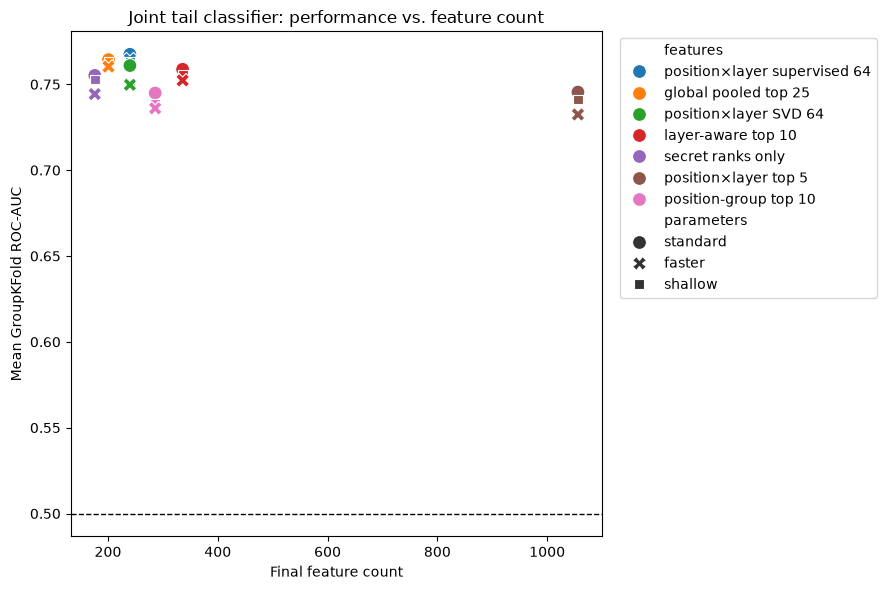

In [9]:
joint_records = load_joint_records()
joint_results = []
for feature_name in JOINT_FEATURE_CONFIGS:
    for parameter_name in JOINT_XGBOOST_CONFIGS:
        joint_results.append({
            "features": feature_name,
            "parameters": parameter_name,
            **evaluate_joint(joint_records, feature_name, parameter_name),
        })
        print("Done", feature_name, "—", parameter_name)

joint_results_df = pd.DataFrame(joint_results).sort_values("mean_fold_auc", ascending=False)
display(joint_results_df)
best_joint = joint_results_df.iloc[0]
display(best_joint.to_frame("selected joint classifier"))

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=joint_results_df,
    x="mean_features",
    y="mean_fold_auc",
    hue="features",
    style="parameters",
    s=100,
)
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xlabel("Final feature count")
plt.ylabel("Mean GroupKFold ROC-AUC")
plt.title("Joint tail classifier: performance vs. feature count")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Interpretation guardrails

- Mean fold ROC-AUC is the primary metric. Accuracy uses a fixed 0.5 threshold and can be misleading because only about 35% of runs leak.
- Fold-local vocabulary selection and reduction prevent held-out categories from influencing the feature space.
- The per-position and joint models combine correlated layers. They localize predictive signal by position or scope, not by individual-layer coefficients.
- `banana` rank features make the compact position and joint classifiers secret-specific.
- Feature and parameter selection on this dataset is exploratory; a final unbiased estimate requires nested grouped validation or a new dataset.